# This Notebook is used to create a visual representation of the edge transoforms from the pose graph.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image
import os

In [2]:
poses=[]
from_ids=[]
to_ids=[]
folder_path = '/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/edge_results'
file_count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
print(f"Number of files: {file_count}")
for i in range(0,file_count,1):
    filename = filename=folder_path+f"/edge_{i:04d}.txt"
    matrix = []
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.startswith('from_vertex_id'):
                # Extract the vertex ID from the line
                from_vertex_id = int(line.split(':')[1].strip())
                # print(f"From Vertex ID: {from_vertex_id}")
                from_ids.append(from_vertex_id)
            elif line.startswith('to_vertex_id'):
                # Extract the vertex ID from the line
                to_vertex_id = int(line.split(':')[1].strip())
                # print(f"To Vertex ID: {to_vertex_id}")
                to_ids.append(to_vertex_id)
            elif line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)

    temp = np.array(matrix[0:4])
    poses.append(np.array(matrix[0:4]))
#poses=np.array(poses)

Number of files: 52


In [3]:
for i in range(0,from_ids.__len__(),1):
    print(f"From Vertex ID: {from_ids[i]}, To Vertex ID: {to_ids[i]}")
    print(f"Pose: {poses[i]}")
    print("")

From Vertex ID: 31, To Vertex ID: 32
Pose: [[ 9.95926e-01 -9.01788e-02 -3.14539e-04 -1.19469e-01]
 [ 9.01788e-02  9.95926e-01 -2.52030e-04  2.54528e-03]
 [ 3.35986e-04  2.22638e-04  1.00000e+00 -1.43215e-03]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]

From Vertex ID: 39, To Vertex ID: 40
Pose: [[ 0.975343   -0.220575    0.00720085 -0.29261   ]
 [ 0.220599    0.975361   -0.00271002 -0.00724812]
 [-0.00642566  0.0042317   0.99997     0.0075582 ]
 [ 0.          0.          0.          1.        ]]

From Vertex ID: 7, To Vertex ID: 8
Pose: [[ 9.99992e-01  3.44943e-03  1.96885e-03 -5.13188e-01]
 [-3.44925e-03  9.99994e-01 -9.39924e-05  5.98341e-04]
 [-1.96916e-03  8.72006e-05  9.99998e-01  1.01337e-02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  1.00000e+00]]

From Vertex ID: 23, To Vertex ID: 24
Pose: [[ 9.95132e-01 -9.85530e-02 -9.17967e-05 -1.46014e-01]
 [ 9.85530e-02  9.95131e-01  1.20907e-03  3.38260e-03]
 [-2.78081e-05 -1.21223e-03  9.99999e-01  4.46952e-04]
 [ 0.00000e+00 

In [4]:
def bubble_sort(arr1, arr2, arr3):
    for i in range(len(arr1)):
        # Last i elements are already in place
        for j in range(0, len(arr1) - i - 1):
            if arr1[j] > arr1[j + 1]:
                # Swap if elements are in the wrong order
                arr1[j], arr1[j + 1] = arr1[j + 1], arr1[j]
                arr2[j], arr2[j + 1] = arr2[j + 1], arr2[j]
                arr3[j], arr3[j + 1] = arr3[j + 1], arr3[j]
    return np.array(arr1), np.array(arr2), np.array(arr3)

# Example usage:
my_list = [5, 2, 9, 1, 5, 6]
sorted_from, sorted_to, sorted_poses = bubble_sort(from_ids.copy(), to_ids.copy(), poses.copy())
print("Sorted list:", sorted_from)
print("Corresponding to list:", sorted_to)

Sorted list: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51]
Corresponding to list: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52]


In [5]:
# creating new matrices:
new_poses = []
pose1 = np.array([
    [-1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]
])
new_poses.append(pose1)
for i in range(0,sorted_from.__len__(),1):
    temp_pose =  new_poses[i] @ sorted_poses[i] 
    new_poses.append(temp_pose)
print(new_poses[0])
new_poses = np.array(new_poses)

[[-1  0  0  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 0  0  0  1]]


In [6]:
origins = new_poses[:, :3, -1]
print(origins[0:3])
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in new_poses])
x= origins[..., 0].flatten()
y= origins[..., 1].flatten()
z= origins[..., 2].flatten()
#print(np.array(x))
# print(type(x))

[[ 0.          0.          0.        ]
 [ 0.545558   -0.0050351   0.00279976]
 [ 1.10460978 -0.00928002  0.01178343]]


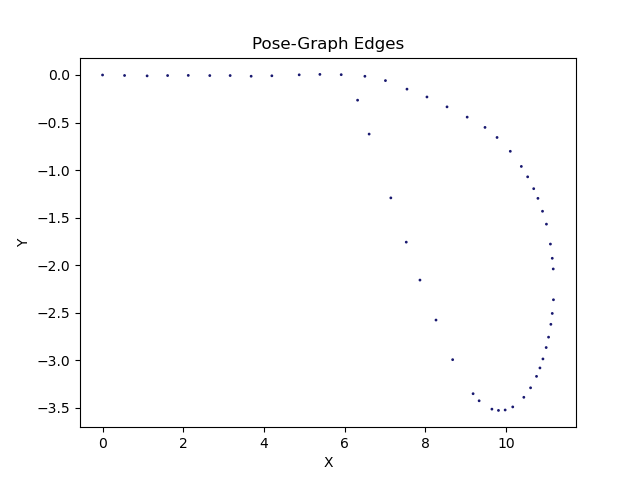

In [7]:
%matplotlib ipympl
s = np.ones(len(x))
#plt.scatter(x=x, y=y, color='red')
plt.scatter(x, y, s=s, color='midnightblue', label='Group 1')
# plt.xlim(0, 35)   
# plt.ylim(-7, 1) 
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Pose-Graph Edges")
# plt.axis('equal')
plt.show()

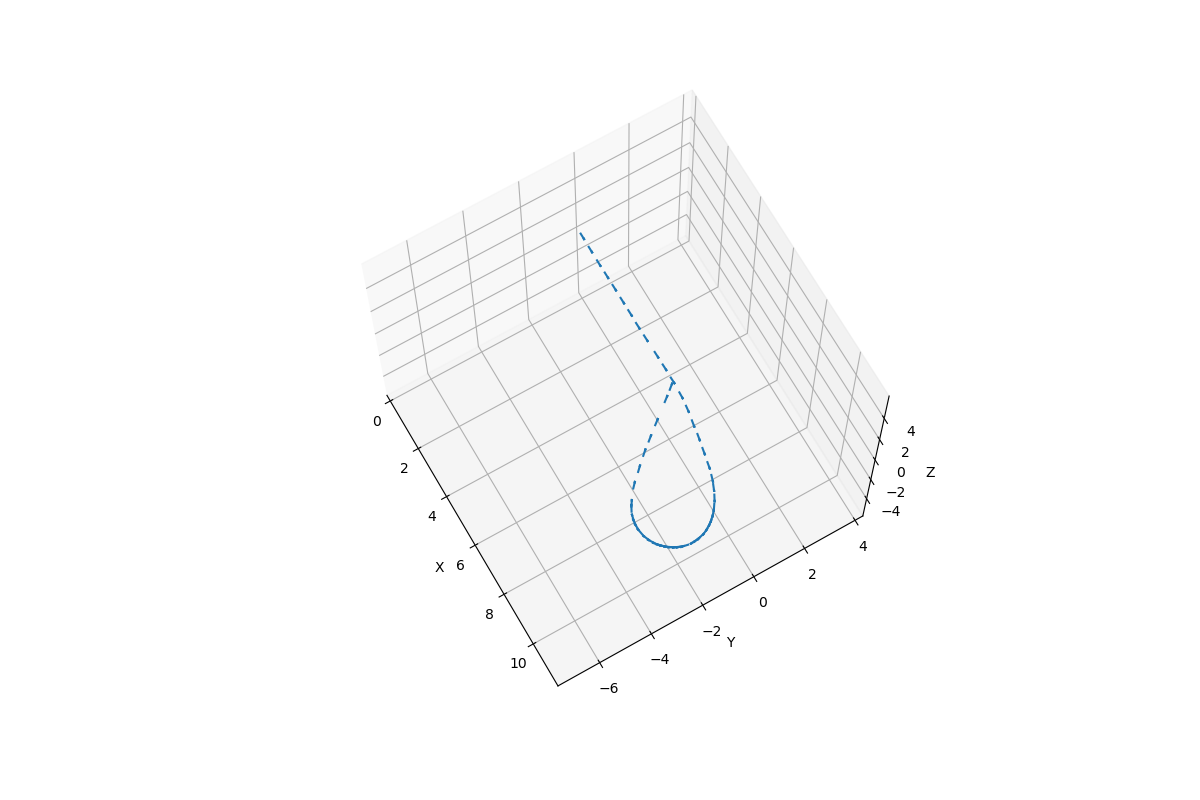

In [10]:
%matplotlib ipympl

all_points = np.concatenate([
    origins.reshape(-1, 3),
    (origins - dirs).reshape(-1, 3)  # quiver tip positions
], axis=0)

x_min, x_max = np.min(all_points[:, 0]), np.max(all_points[:, 0])
y_min, y_max = np.min(all_points[:, 1]), np.max(all_points[:, 1])
z_min, z_max = np.min(all_points[:, 2]), np.max(all_points[:, 2])

# Find the overall center and max range
max_range = max(x_max - x_min, y_max - y_min, z_max - z_min) / 2.0
x_mid = (x_max + x_min) / 2.0
y_mid = (y_max + y_min) / 2.0
z_mid = (z_max + z_min) / 2.0



# print(origins)
ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  -dirs[..., 0].flatten(),
  -dirs[..., 1].flatten(),
  -dirs[..., 2].flatten(), length=0.3, normalize=False)
ax.set_box_aspect([1,1,1])


ax.set_xlim(x_mid - max_range, x_mid + max_range)
ax.set_ylim(y_mid - max_range, y_mid + max_range)
ax.set_zlim(z_mid - max_range, z_mid + max_range)



ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(70, -30) 
plt.show()

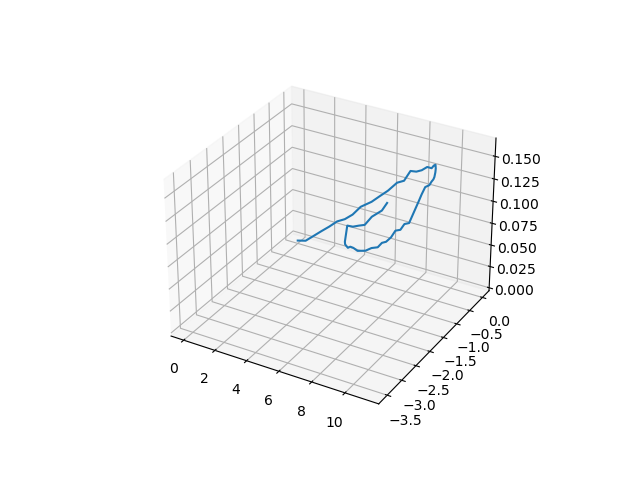

In [9]:
%matplotlib ipympl
ax = plt.axes(projection='3d')
ax.plot3D(x, y, z)